## This notebook performs CWFS for a target, but only measures and does not apply the corrections automatically

#### WARNING: This currently requires ts_externalscripts branch **tickets/DM-28818**

In [15]:
#TARGET='HD 38553'  # will send this to slew_object
#TARGET='HD 34950'  # will send this to slew_object
#TARGET='HD 14556'  # will send this to slew_object
#TARGET='HD 60517'
#TARGET='HD 63214'
#TARGET='HD 185975'

2021-02-19 01:45:45  ATHeaderService.logevent_logMessage check_nitems         WARNING logMessage DDS read queue is filling: 32 of 100 elements


logMessage DDS read queue is filling: 32 of 100 elements


In [2]:
import os
import sys
import asyncio
import time

import numpy as np
import logging 
import yaml
import matplotlib.pyplot as plt
import astropy

from lsst.ts import salobj
from lsst.ts.externalscripts.auxtel.latiss_cwfs_align import LatissCWFSAlign
from lsst.ts.externalscripts.auxtel.latiss_acquire_and_take_sequence import LatissAcquireAndTakeSequence

from lsst.ts.idl.enums.Script import ScriptState


Bad key "text.kerning_factor" on line 4 in
/opt/lsst/software/stack/conda/miniconda3-py37_4.8.2/envs/lsst-scipipe-cb4e2dc/lib/python3.7/site-packages/matplotlib/mpl-data/stylelib/_classic_test_patch.mplstyle.
You probably need to get an updated matplotlibrc file from
http://github.com/matplotlib/matplotlib/blob/master/matplotlibrc.template
or from the matplotlib source distribution
/home/craiglagegit/WORK/ts_externalscripts/python/lsst/ts/externalscripts/auxtel/latiss_acquire_target.py:41: UserWarning: Cannot import lsst.observing. Script will not work.
  warnings.warn("Cannot import lsst.observing. Script will not work.")
/home/craiglagegit/WORK/ts_externalscripts/python/lsst/ts/externalscripts/auxtel/latiss_take_sequence.py:36: UserWarning: Cannot import lsst.observing. Script will not work.
  warnings.warn("Cannot import lsst.observing. Script will not work.")


In [3]:
print(os.environ["OSPL_URI"])
print(os.environ["LSST_DDS_PARTITION_PREFIX"])

file:///home/craiglagegit/WORK/ts_ddsconfig/config/ospl-shmem.xml
summit


In [4]:
# for autocompleted to work
%config IPCompleter.use_jedi = False

In [5]:
stream_handler = logging.StreamHandler(sys.stdout)
# if you want logging
logger = logging.getLogger()
logger.addHandler(stream_handler)
logger.level = logging.DEBUG

# turn off logging for matplotlib and butler ingestion
logging.getLogger("matplotlib").setLevel(logging.WARNING)
logging.getLogger("astro_metadata_translator.headers").setLevel(logging.WARNING)
logging.getLogger("lsst.obs.lsst.translators.latiss").setLevel(logging.WARNING)
logging.getLogger("astro_metadata_translator.translator").setLevel(logging.WARNING)
logging.getLogger("astro_metadata_translator.headers").setLevel(logging.WARNING)

In [6]:
script_cwfs = LatissCWFSAlign(index=3, remotes=True)  # this essentially calls the init method
await script_cwfs.start_task

atmcs: Adding all resources.
atptg: Adding all resources.
ataos: Adding all resources.
atpneumatics: Adding all resources.
athexapod: Adding all resources.
atdome: Adding all resources.
atdometrajectory: Adding all resources.
atcamera: Adding all resources.
atspectrograph: Adding all resources.
atheaderservice: Adding all resources.
atarchiver: Adding all resources.
Read historical data in 0.01 sec
Read 1 history items for RemoteEvent(ATDomeTrajectory, 0, algorithm)
Read 25 history items for RemoteEvent(ATDomeTrajectory, 0, appliedSettingsMatchStart)
Read 1 history items for RemoteEvent(ATDomeTrajectory, 0, authList)
Read 100 history items for RemoteEvent(ATDomeTrajectory, 0, heartbeat)
Read 1 history items for RemoteEvent(ATDomeTrajectory, 0, logLevel)
Read 100 history items for RemoteEvent(ATDomeTrajectory, 0, logMessage)
Read 1 history items for RemoteEvent(ATDomeTrajectory, 0, settingVersions)
Read 1 history items for RemoteEvent(ATDomeTrajectory, 0, settingsApplied)
Read 1 history

2021-02-19 01:35:58  ATPneumatics.mainAirSourcePressure check_nitems         WARNING mainAirSourcePressure DDS read queue is filling: 23 of 100 elements


mainAirSourcePressure DDS read queue is filling: 23 of 100 elements


2021-02-19 01:35:58  ATPtg.timeAndDate check_nitems         ERROR  timeAndDate DDS read queue is full (100 elements); data may be lost


timeAndDate DDS read queue is full (100 elements); data may be lost


...

azEl_mountMotorEncoders DDS read queue is filling: 41 of 100 elements


2021-02-19 01:35:58  ATMCS.logevent_target check_nitems         WARNING target DDS read queue is filling: 16 of 100 elements


target DDS read queue is filling: 16 of 100 elements


2021-02-19 01:35:58  ATMCS.logevent_target check_nitems         WARNING target python read queue is filling: 15 of 100 elements


target python read queue is filling: 15 of 100 elements


In [7]:
# set wrap strategy
# this is required until the ATPtg is updated to not configure the mount for maximum time on target
script_cwfs.atcs.rem.atptg.cmd_raDecTarget.set(azWrapStrategy=1)  # 1 does not unwrap, 0 unwraps

In [209]:
await script_cwfs.atcs.enable()

Enabling all components
Gathering settings.
atdome check is disabled, skipping.
Couldn't get settingVersions event. Using empty settings.
Complete settings for atmcs.
Complete settings for atptg.
Complete settings for ataos.
Complete settings for atpneumatics.
Complete settings for athexapod.
Complete settings for atdometrajectory.
Settings versions: {'atmcs': '                                                                                                                               ', 'atptg': '', 'ataos': 'current', 'atpneumatics': '                                                                                                                               ', 'athexapod': 'summit', 'atdometrajectory': ''}
[atmcs]::[<State.FAULT: 3>, <State.STANDBY: 5>, <State.DISABLED: 1>, <State.ENABLED: 2>]
[atptg]::[<State.ENABLED: 2>]
[ataos]::[<State.ENABLED: 2>]
[atpneumatics]::[<State.ENABLED: 2>]
[athexapod]::[<State.ENABLED: 2>]
[atdome]::<State.ENABLED: 2>
[atdometrajectory]::[<State.EN

2021-02-19 09:02:04  ATAOS.logevent_logMessage check_nitems         WARNING logMessage DDS read queue is filling: 13 of 100 elements


logMessage DDS read queue is filling: 13 of 100 elements


In [183]:
await script_cwfs.atcs.point_azel(14.29, 64.837)

Sending command
Stop tracking.
In Position: True.
Scheduling check coroutines
process as completed...
atmcs: <State.ENABLED: 2>
atptg: <State.ENABLED: 2>
ataos: <State.ENABLED: 2>
atpneumatics: <State.ENABLED: 2>
athexapod: <State.ENABLED: 2>
Got False
Telescope not in position
[Telescope] delta Alt = -000.031 deg; delta Az= -006.028 deg; delta N1 = -000.000 deg; delta N2 = +000.000 deg 
[Telescope] delta Alt = -000.000 deg; delta Az= -002.520 deg; delta N1 = -000.000 deg; delta N2 = +000.000 deg 
[Telescope] delta Alt = -000.000 deg; delta Az= -000.059 deg; delta N1 = -000.000 deg; delta N2 = -000.000 deg 
Got True
Waiting for telescope to settle.
[Telescope] delta Alt = -000.000 deg; delta Az= +000.000 deg; delta N1 = -000.000 deg; delta N2 = -000.000 deg 
Telescope in position.


2021-02-19 07:48:37  ATHeaderService.logevent_logMessage check_nitems         WARNING logMessage DDS read queue is filling: 54 of 100 elements


logMessage DDS read queue is filling: 54 of 100 elements


In [ ]:
#await salobj.set_summary_state(script_cwfs.latiss.rem.atptg, salobj.State.ENABLED)

In [16]:
await script_cwfs.atcs.slew_object(TARGET, rot=270, rot_type=2)

Resetting dropped connection: simbad.u-strasbg.fr
http://simbad.u-strasbg.fr:80 "POST /simbad/sim-script HTTP/1.1" 200 None
Slewing to HD 185975: 20 28 18.7402 -87 28 19.938
Setting rotator position with respect to parallactic angle to 270.0 deg.
Parallactic angle: 158.77600210597112 | Sky Angle: -21.223997894028912
Sending command
Stop tracking.


2021-02-19 01:47:23  ATMCS.logevent_target check_nitems         WARNING target python read queue is filling: 25 of 100 elements


target python read queue is filling: 25 of 100 elements


2021-02-19 01:47:23  ATCS       stop_tracking        WARNING Unknown tracking state: 9


Unknown tracking state: 9


2021-02-19 01:47:23  ATCS       stop_tracking        WARNING Unknown tracking state: 10


Unknown tracking state: 10
In Position: True.
Scheduling check coroutines
process as completed...
atmcs: <State.ENABLED: 2>
atptg: <State.ENABLED: 2>
ataos: <State.ENABLED: 2>
atpneumatics: <State.ENABLED: 2>
athexapod: <State.ENABLED: 2>
atdome: <State.ENABLED: 2>
atdometrajectory: <State.ENABLED: 2>
[Telescope] delta Alt = -051.803 deg; delta Az = +065.584 deg; delta N1 = -000.000 deg; delta N2 = +040.139 deg [Dome] delta Az = +075.221 deg
[Telescope] delta Alt = -048.399 deg; delta Az = +061.704 deg; delta N1 = -000.000 deg; delta N2 = +034.898 deg [Dome] delta Az = +073.401 deg
[Telescope] delta Alt = -042.399 deg; delta Az = +055.704 deg; delta N1 = -000.000 deg; delta N2 = +028.888 deg [Dome] delta Az = +069.401 deg
[Telescope] delta Alt = -036.399 deg; delta Az = +049.703 deg; delta N1 = -000.000 deg; delta N2 = +022.892 deg [Dome] delta Az = +063.351 deg
[Telescope] delta Alt = -030.399 deg; delta Az = +043.703 deg; delta N1 = +000.000 deg; delta N2 = +018.986 deg [Dome] delta 

2021-02-19 01:48:08  ATAOS.logevent_logMessage check_nitems         WARNING logMessage DDS read queue is filling: 16 of 100 elements


logMessage DDS read queue is filling: 16 of 100 elements
[Telescope] delta Alt = +000.000 deg; delta Az = +000.681 deg; delta N1 = +000.000 deg; delta N2 = +000.002 deg [Dome] delta Az = -003.039 deg
[Telescope] delta Alt = +000.000 deg; delta Az = +000.173 deg; delta N1 = +000.000 deg; delta N2 = +000.001 deg [Dome] delta Az = -003.039 deg
[Telescope] delta Alt = -000.000 deg; delta Az = +000.010 deg; delta N1 = +000.000 deg; delta N2 = +000.006 deg [Dome] delta Az = -003.039 deg
Got True
Waiting for telescope to settle.
[Telescope] delta Alt = +000.000 deg; delta Az = -000.001 deg; delta N1 = +000.000 deg; delta N2 = +000.006 deg [Dome] delta Az = -003.039 deg
Telescope in position.


In [ ]:
#await script_cwfs.atcs.rem.ataos.cmd_resetOffset.set_start(axis="x")
#await script_cwfs.atcs.rem.ataos.cmd_resetOffset.set_start(axis="y")
#await script_cwfs.atcs.rem.ataos.cmd_resetOffset.set_start(axis="z")

In [17]:
await script_cwfs.latiss.take_object(1.0, 1, filter='RG610', grating='empty_1')

Generating group_id
OBJECT 0001 - 0001


2021-02-19 01:48:20  ATHeaderService.logevent_logMessage check_nitems         WARNING logMessage DDS read queue is filling: 23 of 100 elements


logMessage DDS read queue is filling: 23 of 100 elements


array([2021021800264])

2021-02-19 01:48:48  ATAOS.logevent_logMessage check_nitems         WARNING logMessage DDS read queue is filling: 10 of 100 elements


logMessage DDS read queue is filling: 10 of 100 elements


In [ ]:
#await script_cwfs.atcs.offset_xy(x=0, y=-250, persistent=False)

In [ ]:
#await script_cwfs.atcs.offset_xy(x=-60, y=120)

In [ ]:
#await script_cwfs.latiss.take_object(5.0, 1, filter='RG610', grating='empty_1')

## ONLY RUN THESE CELLS IF AT THE POLE

In [ ]:
# reset the offsets
#await script_cwfs.atcs.rem.ataos.cmd_resetOffset.set_start(axis='x')
#await script_cwfs.atcs.rem.ataos.cmd_resetOffset.set_start(axis='y')
#await script_cwfs.atcs.rem.ataos.cmd_resetOffset.set_start(axis='z')

In [ ]:
# now add back the values that were used at the pole earlier (which should be the same)
#pole_focus= 0.0
#pole_coma_x = 0.0
#pole_coma_y = 0.0

In [ ]:
#await script_cwfs.atcs.rem.ataos.cmd_offset.set_start(z=pole_focus, x=pole_coma_x, y=pole_coma_y)

## Perform CWFS observations

In [158]:
cwfs_configuration = yaml.safe_dump({"filter": 'RG610', 
                                     "grating": 'empty_1',
                                     "exposure_time": 20,
                                     "acq_exposure_time": 5,
                                     "offset_telescope": True,
                                     "threshold": 0.02,
                                     "comma_threshold": 0.4,
                                     "dataPath": '/project/shared/auxTel/rerun/quickLook'})
print(cwfs_configuration)

acq_exposure_time: 5
comma_threshold: 0.4
dataPath: /project/shared/auxTel/rerun/quickLook
exposure_time: 20
filter: RG610
grating: empty_1
offset_telescope: true
threshold: 0.02



In [113]:
cwfs_configuration = yaml.safe_dump({"filter": 'RG610', 
                                     "grating": 'holo4_003',
                                     "exposure_time": 20,
                                     "acq_exposure_time": 5,
                                     "offset_telescope": True,
                                     "threshold": 0.02,
                                     "comma_threshold": 0.4,
                                     "dataPath": '/project/shared/auxTel/rerun/quickLook'})
print(cwfs_configuration)

acq_exposure_time: 5
comma_threshold: 0.4
dataPath: /project/shared/auxTel/rerun/quickLook
exposure_time: 20
filter: RG610
grating: holo4_003
offset_telescope: true
threshold: 0.02



In [159]:
# Set script state to UNCONFIGURED
# this is required to run the script a 2nd time but otherwise is a no-op
script_cwfs.set_state(ScriptState.UNCONFIGURED)
# Configure the script, which puts the ScriptState to CONFIGURED
cwfs_config_data = script_cwfs.cmd_configure.DataType()
cwfs_config_data.config = cwfs_configuration
await script_cwfs.do_configure(cwfs_config_data)

Using binning factor of 2


In [160]:
# set group ID as before
time_for_groupID=astropy.time.Time.now().isot
group_id_data = script_cwfs.cmd_setGroupId.DataType(
                groupId=time_for_groupID
            )
await script_cwfs.do_setGroupId(group_id_data)

In [13]:
script_cwfs.short_timeout = 10

In [ ]:
# # run acquisition script
# # results = await script_cwfs.run()
# result = script_cwfs.cmd_run.DataType()
# await script_cwfs.do_run(result)
# await script_cwfs.done_task

Calculating x/y offset: 0/0 
Applying Az/El offset: 0.0/0.0 
Telescope not in position.
All axes in position.
Waiting for telescope to settle.
Done


In [144]:
await script_cwfs.latiss.setup_atspec(grating='holo4_003', filter='RG60')

In [150]:
await script_cwfs.latiss.take_object(5.0, 1, filter='RG60', grating='holo4_003')

Generating group_id
OBJECT 0001 - 0001


array([2021021800587])

In [151]:
await script_cwfs.take_intra_extra()

Moving to intra-focal position
ENGTEST 0001 - 0001
Moving to extra-focal position
Taking extra-focal image
ENGTEST 0001 - 0001
Moving hexapod back to zero offset (in-focus) position
intraImage expId for target: 2021021800588
extraImage expId for target: 2021021800589


## Full CWFS loop

The following cell will run the CWFS loop automatically, going over several iterations to colimate and focus the optics.

In [98]:
await script_cwfs.atcs.rem.atptg.cmd_poriginClear.set_start(num=0)

In [99]:
await script_cwfs.atcs.rem.atptg.cmd_poriginClear.set_start(num=1)

In [207]:
# will send this to slew_object
#TARGET='HD 185975'
#TARGET='HD 101341'
#TARGET='HD 114449'
###TARGET='HD 34950'  
###TARGET='HD 14556'  
#TARGET='HD 38553' 
#TARGET='HD 60517'
#TARGET='HD 63214'
#
#TARGET='HD 93521'
#TARGET='HD 116009'
#TARGET='HR 4963'
TARGET='HD 107378'

In [208]:
await script_cwfs.atcs.slew_object(TARGET, rot=270, rot_type=2)

Resetting dropped connection: simbad.u-strasbg.fr
http://simbad.u-strasbg.fr:80 "POST /simbad/sim-script HTTP/1.1" 200 None
Slewing to HD 107378: 12 22 12.8956 -83 19 11.742
Setting rotator position with respect to parallactic angle to 270.0 deg.
Parallactic angle: 28.707348992178044 | Sky Angle: -151.29265100782197
Sending command
Stop tracking.


2021-02-19 08:53:46  ATMCS.logevent_target check_nitems         WARNING target python read queue is filling: 26 of 100 elements


target python read queue is filling: 26 of 100 elements


2021-02-19 08:53:46  ATCS       stop_tracking        WARNING Unknown tracking state: 9


Unknown tracking state: 9


...

2021-02-19 08:54:01  ATCS       check_component_state WARNING atmcs not in <State.ENABLED: 2>: <State.FAULT: 3>


atmcs not in <State.ENABLED: 2>: <State.FAULT: 3>


RuntimeError: atmcs state is <State.FAULT: 3>, expected <State.ENABLED: 2>

2021-02-19 08:54:14  ATAOS.logevent_logMessage check_nitems         WARNING logMessage DDS read queue is filling: 13 of 100 elements


logMessage DDS read queue is filling: 13 of 100 elements


In [202]:
await script_cwfs.atcs.offset_xy(x=254, y=0)

Calculating x/y offset: 254/0 
Applying Az/El offset: 253.7902686146841/-10.31986223195311 
Telescope not in position.
All axes in position.
Waiting for telescope to settle.
Done


In [203]:
await script_cwfs.latiss.take_object(1.0, 1, filter='RG610', grating='empty_1')

Generating group_id
OBJECT 0001 - 0001


array([2021021800690])

2021-02-19 08:41:54  ATAOS.logevent_logMessage check_nitems         WARNING logMessage DDS read queue is filling: 13 of 100 elements


logMessage DDS read queue is filling: 13 of 100 elements


In [206]:
for i in [5]:
    await script_cwfs.atcs.offset_xy(x=254-51*i, y=-200+10*i)
    await script_cwfs.latiss.take_object(2.0, 1, filter='RG610', grating='empty_1')
    

Calculating x/y offset: -1/-150 
Applying Az/El offset: -17.390310637799466/-148.99186922755496 
Telescope not in position.
All axes in position.
Waiting for telescope to settle.
Done
Generating group_id
OBJECT 0001 - 0001


2021-02-19 08:49:29  ATAOS.logevent_logMessage check_nitems         WARNING logMessage DDS read queue is filling: 13 of 100 elements


logMessage DDS read queue is filling: 13 of 100 elements


In [196]:
# Run this to run the loop automatically
await script_cwfs.arun()

CWFS iteration 1 starting...


2021-02-19 08:16:27  Script     run_cwfs             WARNING Intra/Extra images not taken. Running take image sequence.


Intra/Extra images not taken. Running take image sequence.
Moving to intra-focal position
ENGTEST 0001 - 0001
Moving to extra-focal position
Taking extra-focal image
ENGTEST 0001 - 0001
Moving hexapod back to zero offset (in-focus) position
intraImage expId for target: 2021021800671
extraImage expId for target: 2021021800672


2021-02-19 08:17:25  ATAOS.logevent_logMessage check_nitems         WARNING logMessage DDS read queue is filling: 16 of 100 elements


logMessage DDS read queue is filling: 16 of 100 elements


...

target python read queue is filling: 99 of 100 elements
intra_square shape is (112, 112)
extra_square shape is (112, 112)
Running CWFS code using images binned by 2 in each dimension.


2021-02-19 08:19:40  ATAOS.logevent_logMessage check_nitems         WARNING logMessage DDS read queue is filling: 10 of 100 elements


logMessage DDS read queue is filling: 10 of 100 elements


2021-02-19 08:19:41  Script     run_cwfs             WARNING TODO: Negative sign being used infront of calculated Coma-X Zernike! Artifact tha appeared while checking at NCSA. Needs investigation on other platforms!


TODO: Negative sign being used infront of calculated Coma-X Zernike! Artifact tha appeared while checking at NCSA. Needs investigation on other platforms!
Measured [coma-X, coma-Y, focus] zernike coefficients in nm : [-5.870734528288137, 1.0134630148961143, 5.468253147775687]
De-rotated zernike coefficients: [-5.86368213  1.05350039  5.46825315]
Hexapod offset : [-0.02846448 -0.00511408 -0.00116924]
Telescope offsets: [-1.70786858 -0.30684477  0.        ]

Focus (-0.0011692424943840678) and comma (0.028920239002564053) offsets inside tolerance level (0.02). Total focus correction: 0.02718660581539989 mm. Total comma-x correction: -0.04275643570368497 mm. Total comma-y correction: -0.062170378859013824 mm.
Applying telescope offset x/y: -1.7078685814250272/0.30684477322712034.
Persistent x/y offset: -1.7078685814250272/0.30684477322712034
Timed out waiting for offset done events.
Waiting for telescope to settle.
Done
Hexapod LUT Datapoint - HD 63214 - reported hexapod position is, [-3.5

## Manual loop

The following cell takes a more manual approach to cwfs. It will do 1 iteration of the loop, measuring the CWFS corrections but not applying it.

In [ ]:
# Run this script while taking new data
# this will print but not apply the corrections
script_cwfs.intra_visit_id = None
script_cwfs.extra_visit_id = None
results = await script_cwfs.run_cwfs()

In [ ]:
# Apply calculated focus offset
calculated_hexapod_focus_offset = results['hex_offset'][2]
coma_x = results["hex_offset"][0]
coma_y = results["hex_offset"][1]

print(f'Applying hexapod offsets [x,y,z] of [{coma_x:0.5f}, {coma_y:0.5f}, {calculated_hexapod_focus_offset:0.5f}] mm')
#flush summary event
script_cwfs.atcs.rem.ataos.evt_focusOffsetSummary.flush()
await script_cwfs.atcs.rem.ataos.cmd_offset.set_start(z=calculated_hexapod_focus_offset, x=coma_x, y=coma_y)

### Plot donuts

2021-02-19 08:19:56  ATHeaderService.logevent_logMessage check_nitems         WARNING logMessage DDS read queue is filling: 12 of 100 elements


logMessage DDS read queue is filling: 12 of 100 elements


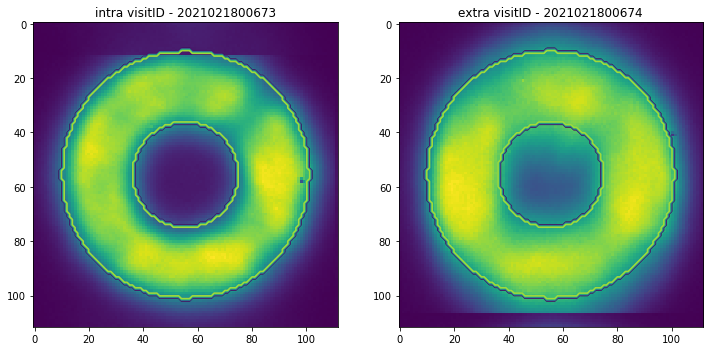

2021-02-19 08:19:57  ATMCS.logevent_target check_nitems         WARNING target python read queue is filling: 10 of 100 elements


target python read queue is filling: 10 of 100 elements


2021-02-19 08:23:51  ATAOS.logevent_logMessage check_nitems         WARNING logMessage DDS read queue is filling: 13 of 100 elements


logMessage DDS read queue is filling: 13 of 100 elements


2021-02-19 08:25:31  ATHeaderService.logevent_logMessage check_nitems         WARNING logMessage DDS read queue is filling: 10 of 100 elements


logMessage DDS read queue is filling: 10 of 100 elements


2021-02-19 08:29:00  ATAOS.logevent_logMessage check_nitems         WARNING logMessage DDS read queue is filling: 10 of 100 elements


logMessage DDS read queue is filling: 10 of 100 elements


In [197]:
%matplotlib inline
# show donuts and centroids
fig1 = plt.figure(1, figsize=(12,8))
ax11 = fig1.add_subplot(121)
ax11.set_title(f"intra visitID - {script_cwfs.intra_visit_id}")
ax11.imshow(script_cwfs.I1[0].image0)
ax11.contour(script_cwfs.algo.pMask) 
ax12 = fig1.add_subplot(122)
ax12.set_title(f"extra visitID - {script_cwfs.extra_visit_id}")
ax12.imshow(script_cwfs.I2[0].image0)
ax12.contour(script_cwfs.algo.pMask) 

## Take the data only

In [ ]:
# Run this to take the data only.
await script_cwfs.take_intra_extra()

In [ ]:
await script_cwfs.latiss.take_object(2.0, 1, filter='RG610', grating='empty_1')

In [ ]:
await script_cwfs.atcs.rem.ataos.cmd_offset.set_start(x=0.348, y=0.188, z=0.67)

In [ ]:
await script_cwfs.atcs.rem.ataos.cmd_offset.set_start(z=0, x=1.8, y=0)

In [ ]:
await script_cwfs.atcs.rem.ataos.cmd_offset.set_start(z=0, x=0, y=-1)

In [ ]:
%matplotlib inline

In [ ]:
# show donuts and centroids
fig1 = plt.figure(1, figsize=(12,8))
ax11 = fig1.add_subplot(121)
ax11.set_title(f"intra visitID - {script_cwfs.intra_visit_id}")
ax11.imshow(script_cwfs.I1[0].image0)
ax11.contour(script_cwfs.algo.pMask) 
ax12 = fig1.add_subplot(122)
ax12.set_title(f"extra visitID - {script_cwfs.extra_visit_id}")
ax12.imshow(script_cwfs.I2[0].image0)
ax12.contour(script_cwfs.algo.pMask) 

In [ ]:
await atcs.take_object(exptime=30)

In [ ]:
# Show which files/parameters were taken in the sequence above
print(f'intra_visit_id is {script_cwfs.intra_visit_id}')
print(f'extra_visit_id is {script_cwfs.extra_visit_id}')
print(f'angle is {script_cwfs.angle}')

In [ ]:
# Apply calculated focus offset
calculated_hexapod_focus_offset = results['hex_offset'][2]
coma_x = results["hex_offset"][0]
coma_y = results["hex_offset"][1]

print(f'Applying hexapod offsets [x,y,z] of [{coma_x:0.5f}, {coma_y:0.5f}, {calculated_hexapod_focus_offset:0.5f}] mm')
#flush summary event
script_cwfs.atcs.rem.ataos.evt_focusOffsetSummary.flush()
await script_cwfs.atcs.rem.ataos.cmd_offset.set_start(z=calculated_hexapod_focus_offset, x=coma_x, y=coma_y)

In [ ]:
await script_cwfs.atcs.rem.ataos.cmd_offset.set_start(x=1.4, y=0.364, z=-0.22)

In [ ]:
await script_cwfs.hexapod_offset(results['hex_offset'][2])

In [ ]:
# Apply telescope offsets
tel_x, tel_y = results["tel_offset"][0], -results["tel_offset"][1]
print(f'Applying telescope offsets [x,y] of [{tel_x:0.2f}, {tel_y:0.2f}] arcsec')
await script_cwfs.atcs.offset_xy(x=tel_x, y=tel_y, relative=True, persistent=True)

In [ ]:
# look at current focus offsets (and paste into the log)
focus_summary = await script_cwfs.atcs.rem.ataos.evt_focusOffsetSummary.next(flush=False, timeout=5)

In [ ]:
print(focus_summary)

In [ ]:
# take a quick object image to check PSF centering
await take_object(exptime=5)

## RUN THIS NEXT CELL ONLY IF DATA IS ACCEPTABLE FOR LUT GENERATION

In [ ]:
tmp = await script_cwfs.atcs.rem.athexapod.tel_positionStatus.next(flush=True, timeout=5)
script_cwfs.log.info(f'Hexapod LUT Datapoint - {TARGET} - reported hexapod position is, {tmp.reportedPosition} ')

#### BELOW IS ONLY FOR TESTING PURPOSES

In [ ]:
# If desired then different filenames can be manually input here
script_cwfs.intra_visit_id=2021011900169 
script_cwfs.extra_visit_id=2021011900170 
script_cwfs.angle=-91.56748047249727

In [ ]:
# reruns reduction part only. ALL 3 fields above must be set! 
rerun_results = await script_cwfs.run_cwfs()

In [ ]:
results=rerun_results